# Great Lakes Surface Water Temperature

> NOAA CoastWatch provides a wide range of satellite environmental data to support the work of coastal scientists and resource managers in all U.S. coastal waters. The CoastWatch Great Lakes Regional Node (GLN) disseminates satellite observation data to governmental, academic, commercial, and public users. The GLN is hosted by the NOAA Great Lakes Environmental Research Laboratory (GLERL), Ann Arbor, Michigan. (Adapted from NOAA CoastWatch)

The Great Lakes Surface Environmental Analysis (GLSEA) is a daily gridded map showing surface water temperature and ice cover of the Great Lakes. GLSEA takes the most recent cloud-free satellite observations and blends them with a transition model (using a daily updating weight) to produce a map of the lakes every single day.

The Advanced Clear-Sky Processor for Oceans (ACSPO) is the underlying algorithm and software system. ACSPO takes raw infrared data from polar-orbiting satellites and geostationary satellites, masks out the clouds, and calculates highly accurate Sea Surface Temperatures (SST).

A Geographic Coordinate System (GCS) means that the data is stored using an unprojected, ellipsoidal coordinate system. Instead of projecting the Earth's curved surface onto a flat 2D plane (like a Mercator or Lambert Conformal Conic projection), a GCS maps data points directly using angular units. GLSEA_ACSPO_GCS is a daily, gridded Great Lakes surface temperature product generated using the ACSPO algorithm and mapped onto a standard, unprojected latitude-longitude GCS.

This notebook was adapted from these CoastWatch tutorials

 - https://coastwatch-training.github.io/tutorials/Tutorial1-basics/python/Tutorial1-basics.html
 - https://coastwatch-training.github.io/tutorials/gl-access-sat-surface-temp-data/python/gl-access-sat-surface-temp-data.html


## 1. Downloading Data via ERDDAP

ERDDAP is a RESTful scientific data server developed by NOAA. Instead of requiring users to download massive, monolithic datasets manually, ERDDAP allows you to build a customized URL that requests only the specific variables, timeframes, and geographic bounding boxes you need. While ERDDAP can dynamically package and serve data in dozens of formats (including CSV, JSON, and HTML tables), this notebook leverages its ability to stream data directly as a NetCDF (`.nc`) file.

In Python, we construct a data request URL that explicitly includes the `.nc` extension alongside our spatial and temporal constraints. Python libraries can then read this streamed file directly into memory as a dataset object. Because ERDDAP is a standardized protocol used across countless scientific institutions, mastering this URL-based syntax allows you to reuse the exact same data-access workflow for a vast range of oceanographic, atmospheric, and environmental servers with only minimal changes to the base address and constraints.

### How ERDDAP URL Syntax Maps to NetCDF and Xarray

The URL construction below is not just a random string; it directly reflects the internal dimensions and coordinate variables of the underlying NetCDF file. 

When you use ERDDAP's standard dimension syntax—`(start):stride:(stop)`—you are executing a remote data slice. Understanding this relationship helps clarify how the URL elements translate once the data is loaded into Python:

1. **The File Extension (`.nc`):** By appending `.nc` to the base URL, you instruct the ERDDAP server to dynamically package the requested data slice into a standard NetCDF binary file structure on the fly.
2. **The Variable (`sst`):** This maps directly to the scientific **Data Variable** inside the NetCDF file. In Xarray, this will become an `xarray.DataArray` nested within your main dataset (`ds.sst`).
3. **The Bracketed Dimensions (`[time][lat][lon]`):** These represent the **Coordinate Dimensions** of the dataset. The order of these brackets must match the exact dimension array ordering on the ERDDAP server. 
4. **The Slice Constraints:** When Python reads this URL, Xarray doesn't have to download the massive historical global or regional dataset. It only pulls the specific coordinate bounds you defined (e.g., Lake Erie's bounding box for June 2023). This is structurally identical to running a local coordinate slice in Xarray, such as:
   `ds.sel(time=slice('2023-06-01', '2023-06-30'), lat=slice(43, 41), lon=slice(-83.5, -78.5))`

In [ ]:
# standard library
import urllib.request
import warnings

import matplotlib.colors as mcolors
#import netCDF4 as nc
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib import pyplot as plt

warnings.filterwarnings('ignore')

In [ ]:
# Construct the url for GLERL ERDDAP server used in this notebook. 

base     = 'https://apps.glerl.noaa.gov/erddap/griddap/GLSEA_ACSPO_GCS'
variable = 'sst'
time     = '(2023-06-01T12:00:00Z):1:(2023-06-30T12:00:00Z)'
#lat     = '(43):1:(41)'          # Lake Erie 
#lon     = '(-83.5):1:(-78.5)'    # Lake Erie
lat      = '(46.2):1:(41.5)'      # Lake Michigan
lon      = '(-88.2):1:(-84.6)'    # Lake Michigan
#lat     = '(49):1:(41)'          # GL 
#lon     = '(-92.5):1:(-75.5)'    # GL

url = f'{base}.nc?{variable}[{time}][{lat}][{lon}]'
print(url)

https://apps.glerl.noaa.gov/erddap/griddap/GLSEA_ACSPO_GCS.nc?sst[(2023-06-01T12:00:00Z):1:(2023-06-30T12:00:00Z)][(46.2):1:(41.5)][(-88.2):1:(-84.6)]


In [263]:
urllib.request.urlretrieve(url, "e_sst.nc")

('e_sst.nc', <http.client.HTTPMessage at 0x7362fec154f0>)

# 2. Importing NetCDF4 data in Python

Now that we've downloaded the data locally, we can import it and extract our variables of interest.

The xarray package makes it very convenient to work with NetCDF files. Documentation is available here:
http://xarray.pydata.org/en/stable/why-xarray.html

#### Open the file and load it as an xarray dataset

In [264]:
ds = xr.open_dataset('e_sst.nc',decode_cf=True)

### NetCDF Dataset Interactivity and Attribute Slicing

Running the variable `ds` as a trailing line without an explicit print function initiates Xarray's customized, **interactive HTML graphical wrapper**. This layout eliminates the need to isolate components manually, mapping directly to your configuration details as follows:

* **Dataset Dimensions (`dims`):** Displays sequential index arrays for space and time frames at the absolute top boundary of the metadata display.
* **Coordinate Context (`coords`):** Slices physical latitude and longitude markers directly with dynamic, drop-down arrows allowing coordinate expansion.
* **Data Variables (`data_vars`):** Features targeted arrays representing physical ocean indicators like Sea Surface Temperature (`sst`).
* **Global Parameters (`attrs`):** Can be unfurled instantly by selecting the document icons (📄) along the horizontal layout bar to inspect origin institutions and calibration limits.

In [265]:
ds

<xarray.Dataset> Size: 10MB
Dimensions:    (time: 30, latitude: 337, longitude: 258)
Coordinates:
  * time       (time) datetime64[ns] 240B 2023-06-01T12:00:00 ... 2023-06-30T...
  * latitude   (latitude) float64 3kB 41.5 41.51 41.52 ... 46.18 46.19 46.21
  * longitude  (longitude) float64 2kB -88.2 -88.19 -88.17 ... -84.61 -84.6
Data variables:
    sst        (time, latitude, longitude) float32 10MB ...
Attributes: (12/37)
    cdm_data_type:                             Grid
    Conventions:                               CF-1.6, COARDS, ACDD-1.3
    Easternmost_Easting:                       -84.5992920656143
    GDAL:                                      GDAL 3.4.3, released 2022/04/22
    geospatial_lat_max:                        46.2051027568914
    geospatial_lat_min:                        41.495888934929
    ...                                        ...
    summary:                                   Sea Surface Temperature (SST) ...
    testOutOfDate:                             now-3days
    time_coverage_end:                         2023-06-30T12:00:00Z
    time_coverage_start:                       2023-06-01T12:00:00Z
    title:                                     Sea Surface Temperature (SST) ...
    Westernmost_Easting:                       -88.2012800187225

#### Choosing the temperature range for the color scale

In [266]:
sst_min = np.floor(float(ds.sst.min()))
sst_max = np.ceil(float(ds.sst.max()))
print('Minimum SST:', sst_min)
print('Maximum SST:', sst_max)

levs = np.arange(sst_min, sst_max + 0.05, 0.05)

Minimum SST: 7.0
Maximum SST: 25.0


#### Building a blue-to-red temperature colormap

In [267]:
# init a color list
jet=["blue", "#007FFF", "cyan","#7FFF7F", "yellow", "#FF7F00", "red", "#7F0000"]
cm = mcolors.LinearSegmentedColormap.from_list('my_jet', jet, N=len(levs))

In [ ]:
# Cities to optionally annotate (Lake Michigan defaults).
# Pass your own dict to plot a different lake.
LAKEFRONT_CITIES = {
    'Chicago':   (-87.63, 41.88),
    'Milwaukee': (-87.91, 43.04),
    'Green Bay': (-88.01, 44.51),
}

def add_cities(ax, cities):
    """Mark city points on a map axis. `cities` maps name -> (lon, lat)."""
    for name, (lon, lat) in cities.items():
        ax.plot(lon, lat, 'ko', markersize=4, zorder=5)
        ax.text(lon + 0.05, lat + 0.03, name, fontsize=9, zorder=5)

def plot_sst(field2d, title, ax=None, levs=levs, cm=cm,
             contour_step=None, cbar_label='SST',
             cities=False, city_list=LAKEFRONT_CITIES):
    """Plot a 2-D SST field on a map.

    field2d : 2-D DataArray (latitude, longitude), already reduced in time.
    title   : caller-supplied string. The function does NOT compute dates,
              so it works for any averaging interval (hour/day/week/month/anomaly).
    ax      : an existing axis (for grids/animation). If None, a new figure is made.
    levs/cm : contour levels and colormap. Defaults to the module globals, but pass
              your own (e.g. a diverging map + symmetric levels) for anomaly plots.
    contour_step : if given, an array of levels for overlaid contour lines.
    cities  : if True, annotate city_list points.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))

    filled = ax.contourf(field2d.longitude, field2d.latitude, field2d,
                         levs, cmap=cm)

    if contour_step is not None:
        ax.contour(field2d.longitude, field2d.latitude, field2d,
                   levels=contour_step, linewidths=1)

    if cities:
        add_cities(ax, city_list)

    # Correct aspect for an unprojected lat/lon grid, derived from the field
    # itself so it adapts automatically if you switch lakes.
    mid_lat = float(field2d.latitude.dropna('latitude').mean())
    ax.set_aspect(1 / np.cos(np.deg2rad(mid_lat)))

    cbar = plt.colorbar(filled, ax=ax)
    cbar.set_label(cbar_label)

    ax.set_title(title)
    return ax

### Create a map of SST for the first time step

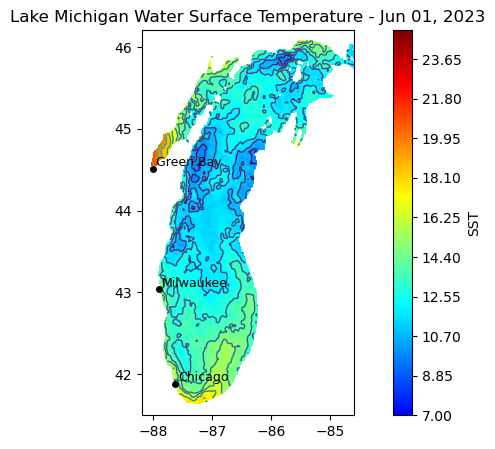

In [269]:
plot_sst(ds.sst[0],
         "Lake Michigan Water Surface Temperature - " + ds.time[0].dt.strftime('%b %d, %Y').item(),
         contour_step=np.arange(9, 26, 1),
         cities=True)
plt.show()

### Creating a map of average SST over a month

In [270]:
mean_sst = ds.sst.mean('time')   # stays a DataArray, keeps coordinates
mean_sst.shape

(337, 258)

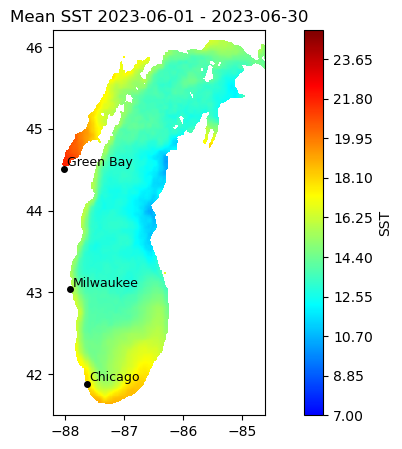

In [271]:
plot_sst(mean_sst,
         "Mean SST " + ds.time[0].dt.strftime('%Y-%m-%d').item() + ' - ' + ds.time[-1].dt.strftime('%Y-%m-%d').item(),
         cities=True)
plt.show()

## Animating SST anomalies to find upwelling events

A single day's SST map is dominated by the seasonal pattern — warm shallows, cold deep basin. To *see* a transient event like wind-driven upwelling, we look at the **anomaly**: each day's temperature minus a trailing 7-day average. This removes the slowly-evolving seasonal background and leaves the short-lived departures.

A sustained cold anomaly hugging the **western shore** is the signature of upwelling: south winds drive surface water offshore (Ekman transport), and cold deep water rises along the coast to replace it. Animating the anomaly day by day lets us watch such a cold tongue appear, persist, and relax.

Two choices make the animation readable:
- **A fixed, symmetric color scale** (blue = cold, red = warm, centered on zero) held constant across every frame — so the same anomaly is the same color in each frame and the eye can track the event.
- **A multiday trailing baseline**, which keeps a week-long event visible for its whole duration. The first BASELINE_DAYS -1 days have no full baseline, so the animation starts on BASELINE_DAYS later

The animation is a *discovery* tool — it shows where and when to look. Confirming a cold band as upwelling still requires checking that sustained southerly winds preceded it.

In [272]:
# Each frame is SST minus a trailing BASELINE_DAYS mean (the "anomaly").
# This is the same "caller owns the temporal reduction" idea as before:
# we hand the animation a ready-made anomaly DataArray.

BASELINE_DAYS = 4

baseline = ds.sst.rolling(time=BASELINE_DAYS, min_periods=BASELINE_DAYS-1).mean()
anom = ds.sst - baseline
anom = anom.isel(time=slice(BASELINE_DAYS - 1, None))   # drop incomplete early frames

# Fixed, symmetric diverging scale for the anomaly panel (blue=cold, red=warm).
anom_levs = np.arange(-4, 4.05, 0.25)
anom_cm   = plt.cm.RdBu_r

print('Animation frames:', anom.sizes['time'])

Animation frames: 27


### Side by side animation

In [273]:
import os
from matplotlib import animation
from IPython.display import HTML

OUTDIR = 'figures'
os.makedirs(OUTDIR, exist_ok=True)

# SST frames must line up with the anomaly's later start (baseline drops early days)
START = BASELINE_DAYS - 1
mid_lat = float(ds.latitude.mean())

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

# Colorbars drawn ONCE. Left uses the SST colormap; right a fixed symmetric
# diverging scale via a ScalarMappable so it doesn't depend on any one frame.
imL0 = axL.contourf(ds.sst.longitude, ds.sst.latitude,
                    ds.sst.isel(time=START), levs, cmap=cm)
smR = plt.cm.ScalarMappable(cmap=anom_cm,
        norm=mcolors.Normalize(vmin=anom_levs[0], vmax=anom_levs[-1]))
fig.colorbar(imL0, ax=axL, label='SST (°C)')
fig.colorbar(smR,  ax=axR, label=f'anomaly vs {BASELINE_DAYS}-day mean (°C)')

def update(frame):
    axL.clear(); axR.clear()
    sst_fld = ds.sst.isel(time=START + frame)
    an_fld  = anom.isel(time=frame)

    axL.contourf(sst_fld.longitude, sst_fld.latitude, sst_fld, levs, cmap=cm)
    add_cities(axL, LAKEFRONT_CITIES)
    axL.set_aspect(1/np.cos(np.deg2rad(mid_lat)))
    axL.set_title('SST')

    axR.contourf(an_fld.longitude, an_fld.latitude, an_fld,
                 anom_levs, cmap=anom_cm, extend='both')
    add_cities(axR, LAKEFRONT_CITIES)
    axR.set_aspect(1/np.cos(np.deg2rad(mid_lat)))
    axR.set_title('SST anomaly')

    fig.suptitle('Lake Michigan — ' + anom.time[frame].dt.strftime('%b %d, %Y').item(),
                 fontsize=14)

anim2 = animation.FuncAnimation(fig, update, frames=anom.sizes['time'],
                                interval=500, blit=False)
plt.close(fig)
HTML(anim2.to_jshtml())

In [274]:
anim2.save(os.path.join(OUTDIR, 'sst_and_anomaly.gif'), writer='pillow', fps=2)
print('saved', os.path.join(OUTDIR, 'sst_and_anomaly.gif'))

saved figures/sst_and_anomaly.gif


#### Subset the data to South Lake Michigan and plot SST

In [275]:
lat_bnds, lon_bnds = [41.0, 43.3], [-88.0, -86.2]
a_sst=ds.sst.sel(latitude=slice(*lat_bnds), longitude=slice(*lon_bnds))

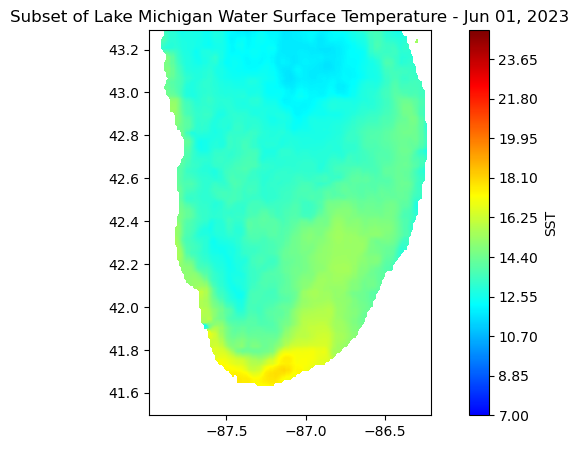

In [276]:
plot_sst(a_sst[0],
         "Subset of Lake Michigan Water Surface Temperature - " + ds.time[0].dt.strftime('%b %d, %Y').item())
plt.show()

#### Reducing each day's map to a single average temperature

In [277]:
res=np.nanmean(a_sst,axis=(1,2))
res


array([13.654606, 14.403964, 14.906861, 15.105953, 15.337391, 14.972628,
       14.417846, 14.119817, 14.2581  , 14.296643, 13.908158, 13.332148,
       13.200683, 13.253238, 13.208662, 13.208207, 13.461647, 14.046634,
       14.727755, 15.238746, 15.699633, 16.087107, 16.46396 , 16.830076,
       16.929283, 16.599749, 16.309223, 16.415218, 16.828722, 17.468807],
      dtype=float32)

### Plotting a time series

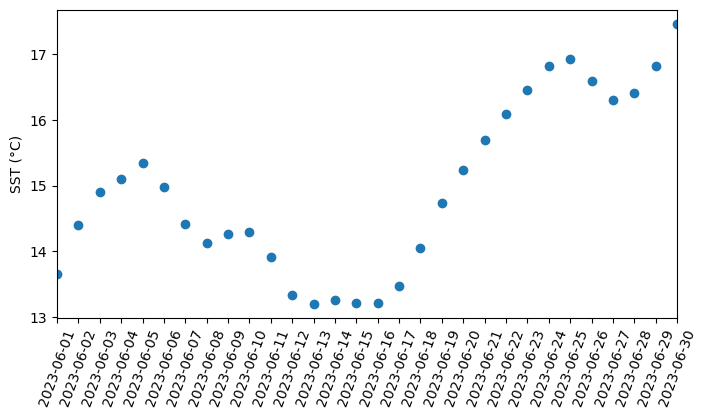

In [278]:
plt.figure(figsize=(8,4))

plt.scatter(ds.time,res)

degree_sign = u"\N{DEGREE SIGN}"
plt.ylabel('SST (' + degree_sign + 'C)')

plt.xlim(ds.time[0], ds.time[-1])

plt.xticks(ds.time,rotation=70, fontsize=10 )
plt.show()